# Process Visualisation — Pipeline Order & Decision Gates

This notebook is **not** a data-analysis notebook — it doesn't load any data or fit any model.
It's a shared, versioned reference for the team: a map of the whole modelling workflow, what
belongs *inside* a cross-validation fold vs. what happens once, and — the thing that's actually
confusing — **when** to reach for hyperparameter tuning, Lasso/PCA, SMOTE, or a different model
family, and **why that order matters**.

Three diagrams:

1. **The big picture** — every stage from EDA to the final holdout score, with a decision gate
   wherever the next step genuinely depends on an answer, not just "do more stuff."
2. **Inside a single cross-validation fold** — what actually gets re-fit every fold, and where
   hyperparameter search wraps around that.
3. **Decision gates, zoomed in** — the "which technique, and when" tree: feature selection
   (Lasso vs. PCA), imbalance handling (`class_weight` vs. SMOTE), and when tuning is worth the
   time it costs.

Then a cheat-sheet table, and where the project actually stands against this map right now.

## How to read these diagrams

| Shape / colour | Meaning |
|---|---|
| Green box | Already done in this project |
| Blue box | Planned / not done yet |
| Amber diamond | Decision gate — the next step depends on the answer |
| Red box | Stop / warning — a rule that must not be broken |
| Dashed arrow | Feedback loop or "only if" path, not the main line |
| Dashed grey outline | A grouping — everything inside gets repeated together |

In [1]:
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch, Polygon

PALETTE = {
    "done": "#2E7D32",
    "next": "#33658A",
    "gate": "#F4A300",
    "stop": "#D62828",
    "note": "#EDEDED",
}
TEXT_ON_DARK = "white"
TEXT_ON_LIGHT = "black"


def draw_box(ax, center, width, height, text, kind="next", fontsize=9.5, wrap=20):
    x, y = center
    color = PALETTE[kind]
    text_color = TEXT_ON_LIGHT if kind in ("gate", "note") else TEXT_ON_DARK
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.3, edgecolor="black", facecolor=color, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, textwrap.fill(text, wrap), ha="center", va="center",
             fontsize=fontsize, color=text_color, zorder=3, linespacing=1.3)


def draw_diamond(ax, center, width, height, text, fontsize=9.0, wrap=18):
    x, y = center
    points = [(x, y + height / 2), (x + width / 2, y), (x, y - height / 2), (x - width / 2, y)]
    diamond = Polygon(points, closed=True, linewidth=1.3, edgecolor="black",
                       facecolor=PALETTE["gate"], zorder=2)
    ax.add_patch(diamond)
    ax.text(x, y, textwrap.fill(text, wrap), ha="center", va="center",
             fontsize=fontsize, color=TEXT_ON_LIGHT, zorder=3, linespacing=1.2)


def draw_arrow(ax, start, end, label=None, dashed=False, color="black", curve=0.0,
               label_offset=(0, 0), fontsize=8.3):
    arrow = FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=13, linewidth=1.3,
        linestyle="--" if dashed else "-", color=color,
        connectionstyle=f"arc3,rad={curve}", zorder=1,
    )
    ax.add_patch(arrow)
    if label:
        mx = (start[0] + end[0]) / 2 + label_offset[0]
        my = (start[1] + end[1]) / 2 + label_offset[1]
        ax.text(mx, my, label, ha="center", va="center", fontsize=fontsize, color=color,
                 zorder=4, bbox={"boxstyle": "round,pad=0.15", "facecolor": "white",
                                  "edgecolor": "none"})


def draw_group(ax, lower_left, width, height, label):
    box = FancyBboxPatch(
        lower_left, width, height, boxstyle="round,pad=0.05,rounding_size=0.1",
        linewidth=1.3, linestyle="--", edgecolor="#666666", facecolor="none", zorder=0,
    )
    ax.add_patch(box)
    ax.text(lower_left[0] + 0.15, lower_left[1] + height - 0.25, label, ha="left", va="top",
             fontsize=9, color="#666666", style="italic", zorder=1)


def add_legend(ax, kinds, loc="lower center", ncol=2, anchor=None):
    labels = {
        "done": "Already done", "next": "Planned / next",
        "gate": "Decision gate", "stop": "Stop / warning",
    }
    handles = [Patch(facecolor=PALETTE[k], edgecolor="black", label=labels[k]) for k in kinds]
    kwargs = {"bbox_to_anchor": anchor} if anchor else {}
    ax.legend(handles=handles, loc=loc, ncol=ncol, fontsize=8.5, frameon=False, **kwargs)


def new_diagram(figsize, xlim, ylim, title):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis("off")
    ax.set_title(title, fontsize=13, weight="bold", pad=14)
    return fig, ax

## 1. End-to-end pipeline — the big picture

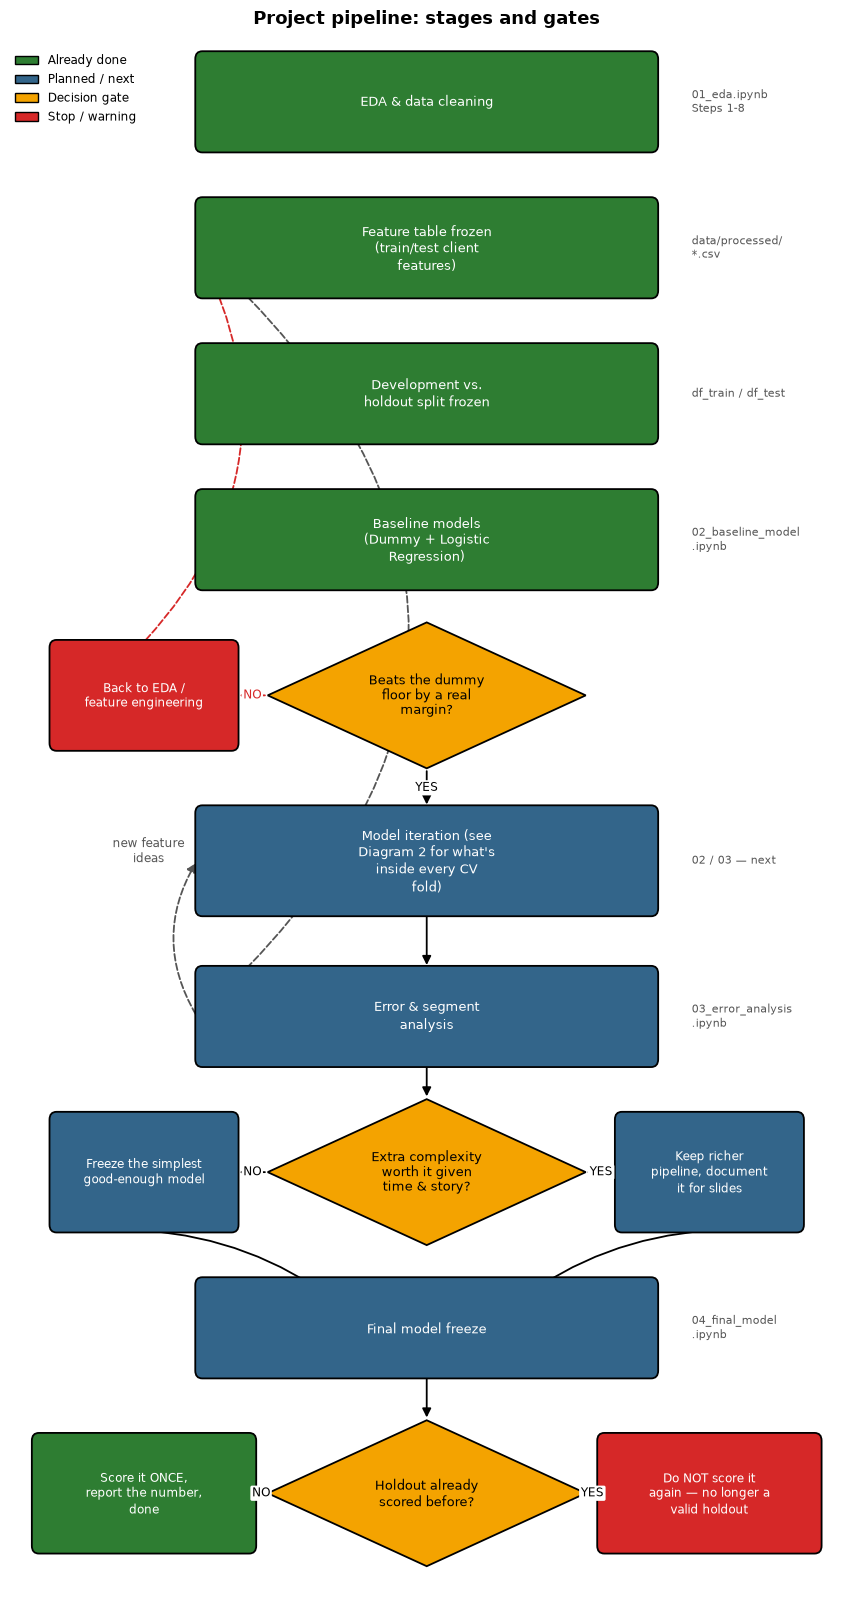

In [2]:
fig, ax = new_diagram((8.5, 16.3), (-4.6, 4.6), (-2.5, 13.6),
                       "Project pipeline: stages and gates")

draw_box(ax, (0, 13), 5.2, 1.0, "EDA & data cleaning", "done")
ax.text(3.0, 13, "01_eda.ipynb\nSteps 1-8", fontsize=8, color="#555555", va="center")

draw_box(ax, (0, 11.5), 5.2, 1.0, "Feature table frozen\n(train/test client features)", "done")
ax.text(3.0, 11.5, "data/processed/\n*.csv", fontsize=8, color="#555555", va="center")

draw_box(ax, (0, 10), 5.2, 1.0, "Development vs. holdout\nsplit frozen", "done")
ax.text(3.0, 10, "df_train / df_test", fontsize=8, color="#555555", va="center")

draw_box(ax, (0, 8.5), 5.2, 1.0, "Baseline models\n(Dummy + Logistic Regression)", "done")
ax.text(3.0, 8.5, "02_baseline_model\n.ipynb", fontsize=8, color="#555555", va="center")

draw_diamond(ax, (0, 6.9), 3.6, 1.5, "Beats the dummy\nfloor by a real\nmargin?")
draw_box(ax, (-3.2, 6.9), 2.1, 1.1, "Back to EDA /\nfeature engineering", "stop", fontsize=8.5)
draw_arrow(ax, (-1.8, 6.9), (-2.15, 6.9), "NO", color=PALETTE["stop"])
draw_arrow(ax, (-3.2, 7.45), (-2.6, 11.5), dashed=True, color=PALETTE["stop"], curve=0.35)

draw_box(ax, (0, 5.2), 5.2, 1.1, "Model iteration\n(see Diagram 2 for what's\ninside every CV fold)", "next")
draw_arrow(ax, (0, 6.15), (0, 5.75), "YES")
ax.text(3.0, 5.2, "02 / 03 — next", fontsize=8, color="#555555", va="center")

draw_box(ax, (0, 3.6), 5.2, 1.0, "Error & segment analysis", "next")
ax.text(3.0, 3.6, "03_error_analysis\n.ipynb", fontsize=8, color="#555555", va="center")
draw_arrow(ax, (0, 4.65), (0, 4.1))
draw_arrow(ax, (-2.6, 3.6), (-2.6, 5.2), dashed=True, color="#555555", curve=-0.3,
           label="new feature\nideas", label_offset=(-0.55, 0.9))
draw_arrow(ax, (-2.6, 3.6), (-2.6, 11.5), dashed=True, color="#555555", curve=0.55)

draw_diamond(ax, (0, 2.0), 3.6, 1.5, "Extra complexity\nworth it given time\n& story?")
draw_arrow(ax, (0, 3.1), (0, 2.75))
draw_box(ax, (-3.2, 2.0), 2.1, 1.2, "Freeze the simplest\ngood-enough model", "next", fontsize=8.5)
draw_box(ax, (3.2, 2.0), 2.1, 1.2, "Keep richer pipeline,\ndocument it for slides", "next", fontsize=8.5)
draw_arrow(ax, (-1.8, 2.0), (-2.15, 2.0), "NO")
draw_arrow(ax, (1.8, 2.0), (2.15, 2.0), "YES")

draw_box(ax, (0, 0.4), 5.2, 1.0, "Final model freeze", "next")
ax.text(3.0, 0.4, "04_final_model\n.ipynb", fontsize=8, color="#555555", va="center")
draw_arrow(ax, (-3.2, 1.4), (-1.0, 0.65), curve=-0.15)
draw_arrow(ax, (3.2, 1.4), (1.0, 0.65), curve=0.15)

draw_diamond(ax, (0, -1.3), 3.6, 1.5, "Holdout already\nscored before?")
draw_arrow(ax, (0, -0.1), (0, -0.55))
box_stop_y = -1.3
draw_box(ax, (3.2, -1.3), 2.5, 1.2, "Do NOT score it\nagain — no longer\na valid holdout", "stop", fontsize=8.5)
draw_box(ax, (-3.2, -1.3), 2.5, 1.2, "Score it ONCE,\nreport the number,\ndone", "done", fontsize=8.5)
draw_arrow(ax, (1.8, -1.3), (1.95, -1.3), "YES")
draw_arrow(ax, (-1.8, -1.3), (-1.95, -1.3), "NO")

add_legend(ax, ["done", "next", "gate", "stop"], loc="upper left", ncol=1,
           anchor=(-0.02, 1.0))
plt.tight_layout()
plt.show()

## 2. What happens inside a single cross-validation fold

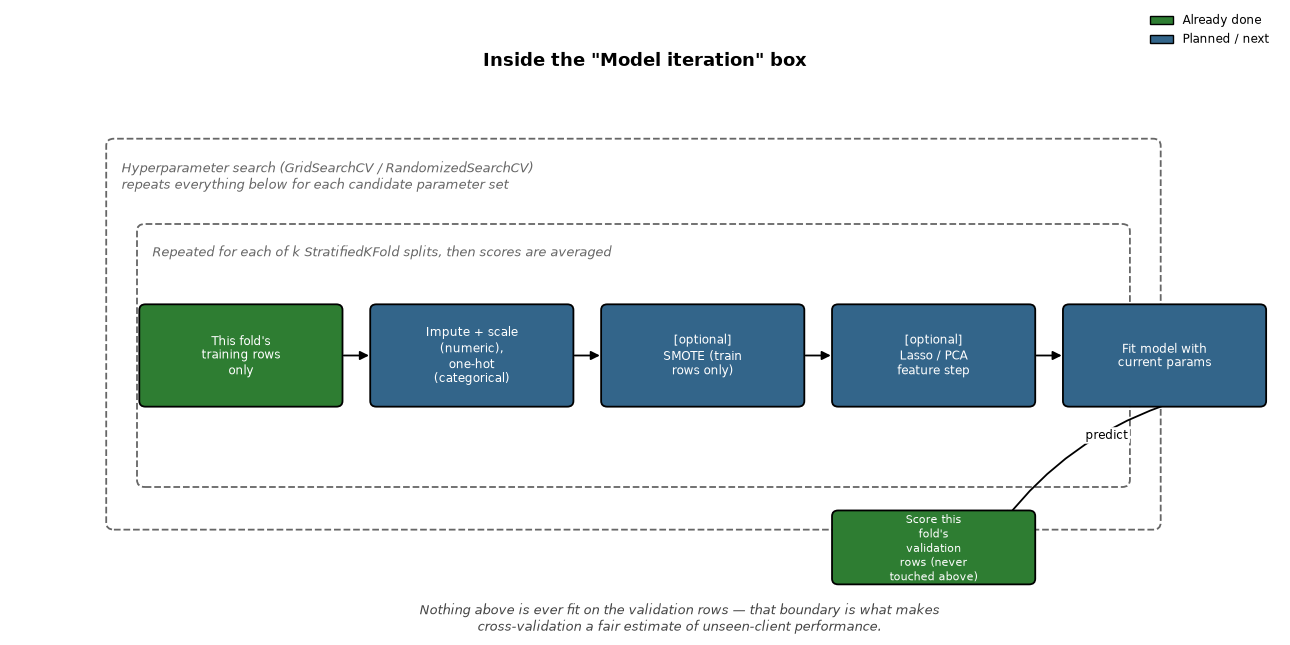

In [3]:
fig, ax = new_diagram((13, 6.5), (-1, 15.5), (-1.2, 6.5),
                       "Inside the \"Model iteration\" box")

draw_group(ax, (0.3, 0.3), 13.6, 5.4, "Hyperparameter search (GridSearchCV / RandomizedSearchCV)\nrepeats everything below for each candidate parameter set")
draw_group(ax, (0.7, 0.9), 12.8, 3.6, "Repeated for each of k StratifiedKFold splits, then scores are averaged")

draw_box(ax, (2.0, 2.7), 2.6, 1.4, "This fold's\ntraining rows\nonly", "done", fontsize=8.5, wrap=14)
draw_box(ax, (5.0, 2.7), 2.6, 1.4, "Impute + scale\n(numeric),\none-hot (categorical)", "next", fontsize=8.5, wrap=14)
draw_box(ax, (8.0, 2.7), 2.6, 1.4, "[optional]\nSMOTE\n(train rows only)", "next", fontsize=8.5, wrap=14)
draw_box(ax, (11.0, 2.7), 2.6, 1.4, "[optional]\nLasso / PCA\nfeature step", "next", fontsize=8.5, wrap=14)
draw_box(ax, (14.0, 2.7), 2.6, 1.4, "Fit model with\ncurrent params", "next", fontsize=8.5, wrap=14)

draw_arrow(ax, (3.3, 2.7), (3.7, 2.7))
draw_arrow(ax, (6.3, 2.7), (6.7, 2.7))
draw_arrow(ax, (9.3, 2.7), (9.7, 2.7))
draw_arrow(ax, (12.3, 2.7), (12.7, 2.7))

draw_box(ax, (11.0, 0.0), 2.6, 1.0, "Score this fold's\nvalidation rows\n(never touched above)", "done", fontsize=8, wrap=14)
draw_arrow(ax, (14.0, 2.0), (11.9, 0.35), curve=0.15,
           label="predict", label_offset=(0.3, 0.4))

ax.text(7.7, -1.0,
        "Nothing above is ever fit on the validation rows — that boundary is what makes\n"
        "cross-validation a fair estimate of unseen-client performance.",
        ha="center", va="center", fontsize=9, style="italic", color="#444444")

add_legend(ax, ["done", "next"], loc="upper right", ncol=1, anchor=(1.0, 1.15))
plt.tight_layout()
plt.show()

## 3. Decision gates — which technique, and when

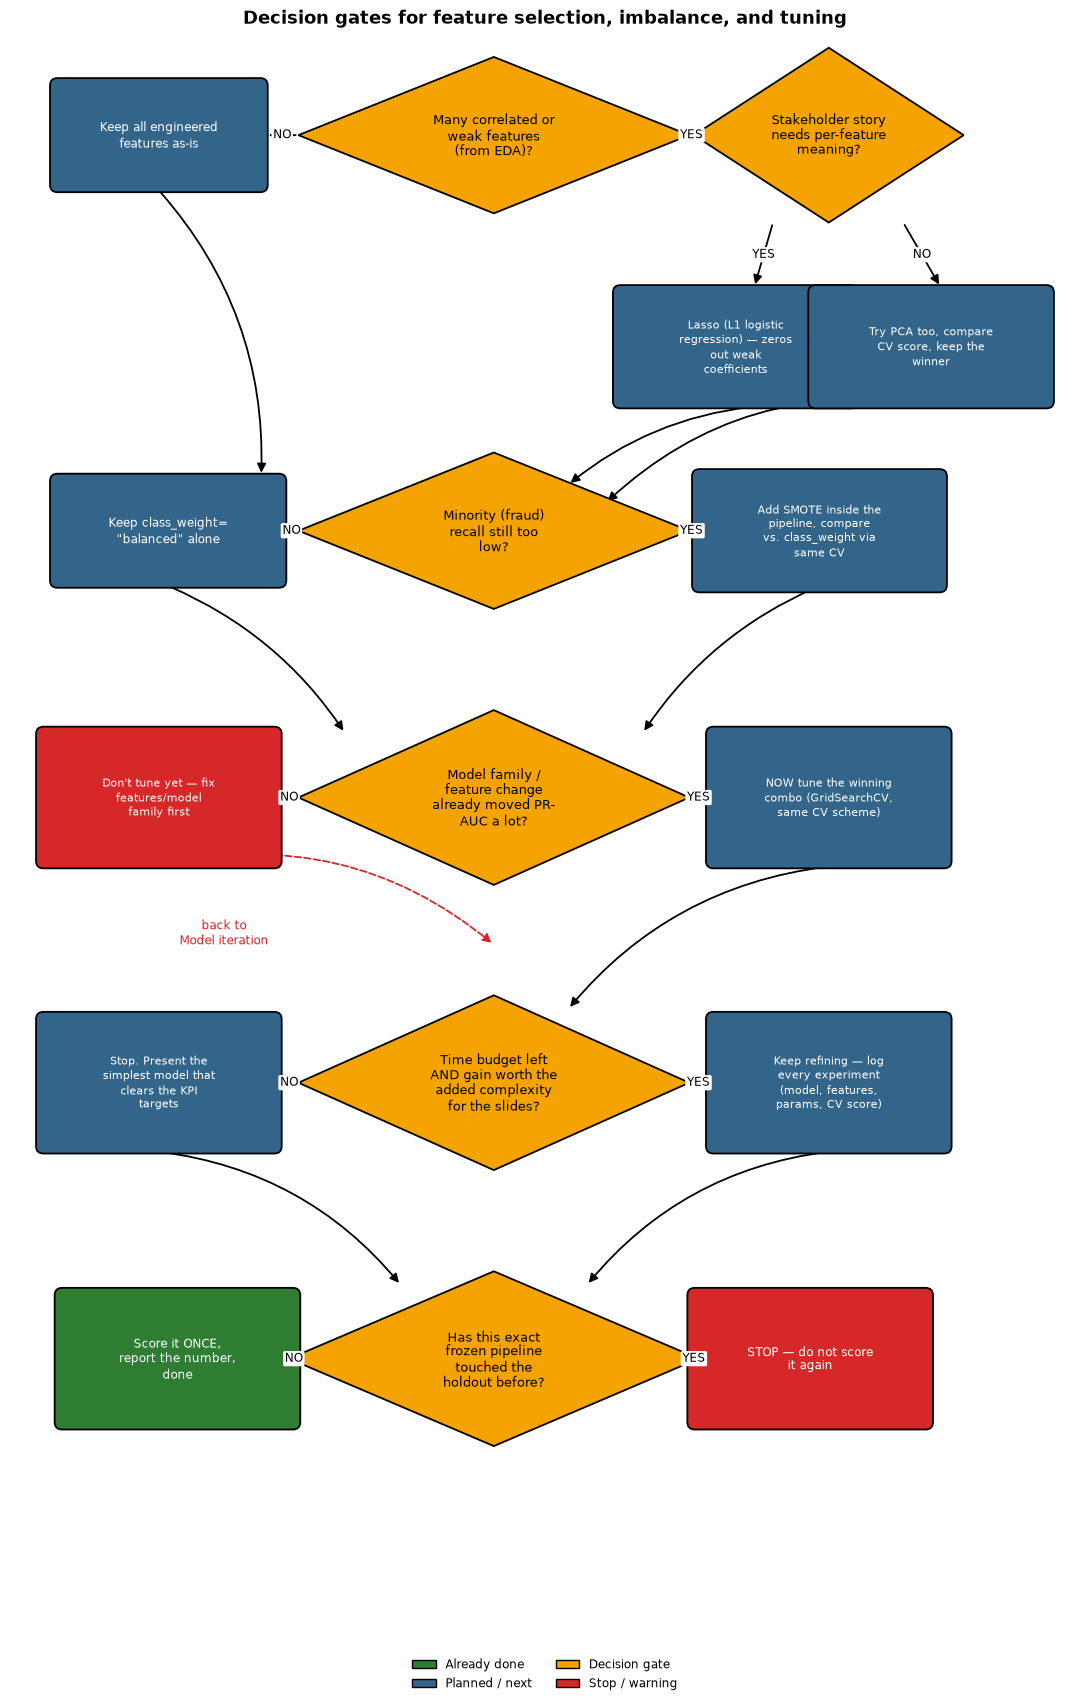

In [4]:
fig, ax = new_diagram((11, 17), (-5.2, 6.3), (-1.5, 15.5),
                       "Decision gates for feature selection, imbalance, and tuning")

draw_diamond(ax, (0, 14.5), 4.2, 1.7, "Many correlated\nor weak features\n(from EDA)?")
draw_box(ax, (-3.6, 14.5), 2.3, 1.2, "Keep all engineered\nfeatures as-is", "next", fontsize=8.3)
draw_arrow(ax, (-2.1, 14.5), (-2.45, 14.5), "NO")

draw_diamond(ax, (3.6, 14.5), 2.9, 1.9, "Stakeholder story\nneeds per-feature\nmeaning?")
draw_arrow(ax, (2.1, 14.5), (2.15, 14.5), "YES")
draw_box(ax, (2.6, 12.2), 2.6, 1.3, "Lasso (L1 logistic\nregression) — zeros out\nweak coefficients", "next", fontsize=8)
draw_box(ax, (4.7, 12.2), 2.6, 1.3, "Try PCA too, compare\nCV score, keep\nthe winner", "next", fontsize=8)
draw_arrow(ax, (3.0, 13.55), (2.8, 12.85), "YES")
draw_arrow(ax, (4.4, 13.55), (4.8, 12.85), "NO")

draw_diamond(ax, (0, 10.2), 4.2, 1.7, "Minority (fraud)\nrecall still\ntoo low?")
draw_arrow(ax, (-3.6, 13.9), (-2.5, 10.8), curve=-0.2)
draw_arrow(ax, (2.8, 11.55), (0.8, 10.7), curve=0.15)
draw_arrow(ax, (4.7, 11.55), (1.2, 10.5), curve=0.25)
draw_box(ax, (-3.5, 10.2), 2.5, 1.2, "Keep class_weight=\n\"balanced\" alone", "next", fontsize=8.3)
draw_box(ax, (3.5, 10.2), 2.7, 1.3, "Add SMOTE inside the\npipeline, compare vs.\nclass_weight via same CV", "next", fontsize=8)
draw_arrow(ax, (-2.1, 10.2), (-2.25, 10.2), "NO")
draw_arrow(ax, (2.1, 10.2), (2.15, 10.2), "YES")

draw_diamond(ax, (0, 7.3), 4.2, 1.9, "Model family /\nfeature change already\nmoved PR-AUC a lot?")
draw_arrow(ax, (-3.5, 9.6), (-1.6, 8.0), curve=-0.15)
draw_arrow(ax, (3.5, 9.6), (1.6, 8.0), curve=0.15)
draw_box(ax, (-3.6, 7.3), 2.6, 1.5, "Don't tune yet —\nfix features/model\nfamily first", "stop", fontsize=8)
draw_box(ax, (3.6, 7.3), 2.6, 1.5, "NOW tune the winning\ncombo (GridSearchCV,\nsame CV scheme)", "next", fontsize=8)
draw_arrow(ax, (-2.1, 7.3), (-2.3, 7.3), "NO")
draw_arrow(ax, (2.1, 7.3), (2.3, 7.3), "YES")
draw_arrow(ax, (-3.6, 6.55), (0, 5.7), dashed=True, color=PALETTE["stop"], curve=-0.25,
           label="back to\nModel iteration", label_offset=(-1.1, -0.3))

draw_diamond(ax, (0, 4.2), 4.2, 1.9, "Time budget left AND\ngain worth the added\ncomplexity for the slides?")
draw_arrow(ax, (3.6, 6.55), (0.8, 5.0), curve=0.2)
draw_box(ax, (-3.6, 4.2), 2.6, 1.5, "Stop. Present the\nsimplest model that\nclears the KPI targets", "next", fontsize=8)
draw_box(ax, (3.6, 4.2), 2.6, 1.5, "Keep refining — log\nevery experiment\n(model, features,\nparams, CV score)", "next", fontsize=8)
draw_arrow(ax, (-2.1, 4.2), (-2.3, 4.2), "NO")
draw_arrow(ax, (2.1, 4.2), (2.3, 4.2), "YES")

draw_diamond(ax, (0, 1.2), 4.4, 1.9, "Has this exact frozen\npipeline touched the\nholdout before?")
draw_arrow(ax, (-3.6, 3.45), (-1.0, 2.0), curve=-0.2)
draw_arrow(ax, (3.6, 3.45), (1.0, 2.0), curve=0.2)
draw_box(ax, (3.4, 1.2), 2.6, 1.5, "STOP — do not\nscore it again", "stop", fontsize=8.3)
draw_box(ax, (-3.4, 1.2), 2.6, 1.5, "Score it ONCE,\nreport the\nnumber, done", "done", fontsize=8.3)
draw_arrow(ax, (2.2, 1.2), (2.1, 1.2), "YES")
draw_arrow(ax, (-2.2, 1.2), (-2.1, 1.2), "NO")

add_legend(ax, ["done", "next", "gate", "stop"], loc="lower center", ncol=2,
           anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

## Cheat sheet: techniques at a glance

| Technique | What it does | When to reach for it | Cost / risk | Library |
|---|---|---|---|---|
| Cross-validation (`StratifiedKFold`) | Estimates how a choice generalises, over several train/validation splits | Always — for every comparison from the first baseline onward | Cheap; just refits the pipeline k times | `sklearn.model_selection` |
| Hyperparameter tuning (`GridSearchCV` / `RandomizedSearchCV`) | Searches model settings (e.g. regularisation strength, tree depth) for the best CV score | Only once model family + features are settled — tuning a weak feature set just optimises the wrong thing | Most expensive step; scales with grid size × folds | `sklearn.model_selection` |
| Lasso (L1 logistic regression) | Shrinks weak coefficients to exactly zero → automatic feature selection + regularisation | Many correlated/weak features, and per-feature meaning still matters | Cheap — one extra fit with `penalty="l1"` | `sklearn.linear_model` |
| PCA | Compresses correlated numeric features into fewer uncorrelated components | Same "too many correlated features" situation, when per-feature meaning isn't needed | Loses interpretability; must be fit inside each CV fold only | `sklearn.decomposition` |
| `class_weight="balanced"` | Reweights the loss so the rare class matters more, without touching the data | First, cheapest response to the ~5.6% imbalance | Free — one constructor argument | built into most `sklearn` classifiers |
| SMOTE | Synthesises new minority-class training rows to rebalance a fold | If `class_weight` alone isn't enough, or a model has no `class_weight` option | Must sit inside `imblearn.pipeline.Pipeline`, training fold only — real leakage risk otherwise | `imbalanced-learn` |
| Tree ensembles (Random Forest / Gradient Boosting) | Capture non-linear effects & feature interactions logistic regression can't | Right after the linear baseline, before heavy tuning of the linear model | Slower to fit/tune; less directly interpretable | `sklearn.ensemble` |
| Threshold / top-k tuning | Converts a probability into a yes/no decision at the actual inspection capacity | After model + features are frozen, to turn PR-AUC into precision@k/recall@k | Cheap — a cutoff on scores already computed | plain `numpy`/`pandas` (already in `02_baseline_model.ipynb`) |

## Where we are right now

Walking this map against the real numbers from `02_baseline_model.ipynb`:

- **Gate A** ("beats the dummy floor by a real margin?"): **yes** — logistic regression's
  PR-AUC (0.173) is 3.1x the dummy floor (0.056), and precision@10%/recall@10% already clear
  the worksheet's KPI targets. No need to loop back to feature engineering yet.
- **Gate 3** ("model family / feature change already moved PR-AUC a lot?"): not tested yet —
  the only model family tried so far is logistic regression. Per this gate, the recommended
  next step is trying a **tree ensemble** (Random Forest or Gradient Boosting) *before* spending
  time hyperparameter-tuning the logistic regression baseline further, since a family change
  usually moves PR-AUC more than tuning a single model's settings.
- **Gates 1 / 2** (feature selection, SMOTE): not needed yet — nothing so far indicates the
  ~50 engineered features are so correlated or redundant that Lasso/PCA are worth the added
  complexity, and `class_weight="balanced"` hasn't been shown insufficient.
- **Gate C / Gate 5** (holdout): untouched — `test_client_features.csv` has not been scored by
  anything yet, and per this map it should stay that way until a model is actually frozen.